In [8]:
# to be able to import frmo another ipynb 
!pip install import-ipynb

In [9]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler , MinMaxScaler
import seaborn as sns



1. Longitudinal Revenue Trends (Annual & Monthly Seasonality)

    - Key Goal: Identify macro-level revenue trajectory, year-over-year (YoY) growth rates, and any seasonal dips or spikes 
    - What to look at: Aggregate total `Sales` by year and month to track historical growth from 2017 to 2020.

In [47]:
df = pd.read_csv('C:/users/jagmeet/vsc/data/new_df.csv')



Pull out both month and year for assessment of peak to peak distribution over time

use pd.categorical - to create a specific checklist order and sort the values accordingly, 
then sort the df via years then the (pre ordered) months. 
The need for pd.categorical > sort_values for ordering months = employs a specific checklist order (months jan to dec. in that order) instead of doing it alphabetically - which is what sort_values does. 

In [48]:
# sort
sorted  = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(df['Month'], categories = sorted, ordered = True)
df = df.sort_values(['Year', 'Month'])
df

,Unnamed: 0,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team,calc_sales
40464,40484,Gerlach LLC,Fadel-West Pharmacy,Ditzingen,Germany,48.8264,9.0667,Hospital,Government,Exotropin Empizine,Mood Stabilizers,20.0,785,15700.0,January,2017,Sheila Stones,Britanny Bold,Delta,15700.0
40465,40485,Gerlach LLC,Nader-Gaylord Pharmacy,Backnang,Germany,48.9464,9.4306,Hospital,Private,Robapril,Antipiretics,10.0,453,4530.0,January,2017,Stella Given,Alisha Cordwell,Charlie,4530.0
40466,40486,Gerlach LLC,McKenzie-Zemlak Pharm,Rheinbach,Germany,50.6256,6.9491,Pharmacy,Institution,Secrelazine Insonamic,Antipiretics,25.0,694,17350.0,January,2017,Daniel Gates,Alisha Cordwell,Charlie,17350.0
40467,40487,Gerlach LLC,Fritsch-Hauck Pharmaceutical Ltd,Fürth,Germany,49.4783,10.9903,Pharmacy,Retail,Megenorphine,Antimalarial,5.0,402,2010.0,January,2017,Mary Gerrard,Britanny Bold,Delta,2010.0
40468,40488,Gerlach LLC,"Bernier, Murphy and Rau Pharma Plc",Geldern,Germany,51.5197,6.3325,Hospital,Government,Agalsiline,Mood Stabilizers,20.0,64,1280.0,January,2017,Mary Gerrard,Britanny Bold,Delta,1280.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251444,254077,Bashirian-Kassulke,"Koch, Borer and Hagenes Pharmaceutical Ltd",Lauf,Germany,49.5103,11.2772,Hospital,Private,Pentastrin,Antibiotics,919.0,497,456743.0,December,2020,Thompson Crawford,James Goodwill,Alfa,456743.0
251445,254078,Bashirian-Kassulke,Hane Ltd Pharmaceutical Ltd,Aichach,Germany,48.4500,11.1333,Hospital,Private,Abranatal Lysoprosate,Antiseptics,432.0,681,294192.0,December,2020,Anne Wu,Britanny Bold,Delta,294192.0
251446,254079,Bashirian-Kassulke,Harris-Conroy Pharmacy,Wilhelmshaven,Germany,53.5167,8.1333,Pharmacy,Retail,Adideine,Mood Stabilizers,320.0,678,216960.0,December,2020,Abigail Thompson,Tracy Banks,Bravo,216960.0
251447,254080,Bashirian-Kassulke,Balistreri Group Pharm,Böblingen,Germany,48.6833,9.0000,Hospital,Government,Feruprazole,Mood Stabilizers,565.0,115,64975.0,December,2020,Stella Given,Alisha Cordwell,Charlie,64975.0


In [51]:
group_values = df.groupby(['Year', 'Month'])['Sales'].sum()
group_values

Year  Month    
2017  January      1.519673e+08
      February     2.109997e+08
      March        2.158317e+08
      April        1.902301e+08
      May          2.251672e+08
      June         2.696262e+08
      July         2.611050e+08
      August       2.352032e+08
      September    2.607565e+08
      October      2.209966e+08
      November     2.545023e+08
      December     2.215439e+08
2018  January      2.554444e+08
      February     2.790366e+08
      March        3.844546e+08
      April        2.491795e+08
      May          2.363142e+08
      June         3.679307e+08
      July         3.118436e+08
      August       2.839474e+08
      September    2.953416e+08
      October      3.621878e+08
      November     3.030801e+08
      December     2.168396e+08
2019  January      9.878078e+07
      February     2.893242e+08
      March        3.036970e+08
      April        2.312609e+08
      May          2.113103e+08
      June         2.057085e+08
      July         2.048

In [52]:
#establish x and y axis for plotting both years and months sales groupings.
x_axis = group_values.index.to_list()
group_values= pd.DataFrame(group_values)
group_values
y_axis = np.array(group_values['Sales'])

range = max(y_axis) - min(y_axis)
range # 387089366.0 -very large rnage therefore the data must be scaled.

# double check via different method
print(np.ptp(y_axis)) # 387089366.0 - same sesulting range 

# scale:
# data must be reshaped into matrix for scaler to work: (n_samples, n_features) NOT 1D array eg (120, )
y_axis = y_axis.reshape(-1,1)
scaler = StandardScaler()
y_axis_scaled = scaler.fit_transform(y_axis)

y_axis_scaled = y_axis_scaled.flatten() #change back into origonal shape (Array)

387089366.0


Text(0, 0.5, 'Sales')

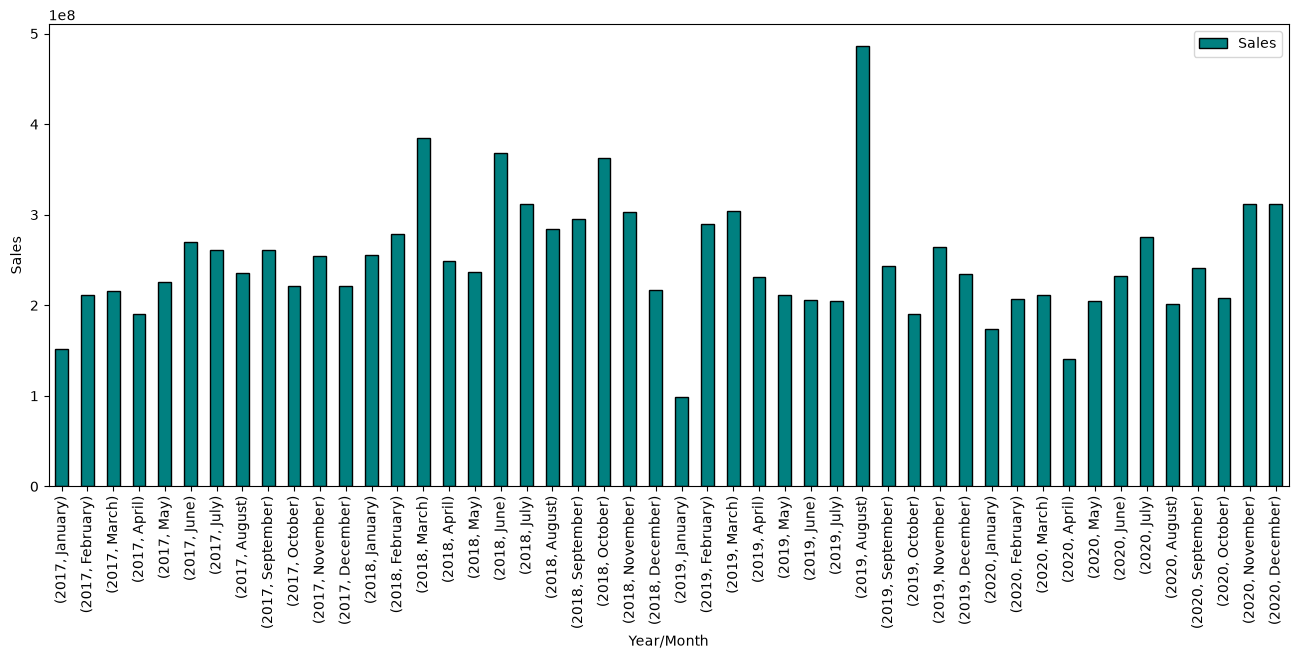

In [53]:

fig, ax = plt.subplots(1,1, figsize = (16,6))
group_values.plot(kind = 'bar', ax = ax, color = 'teal', edgecolor = 'black')
ax.set_xlabel('Year/Month')
ax.set_ylabel('Sales')

2. Geographic & Spatial Performance Mapping

    - Key Goal: Discover which regions generate the highest revenue concentrations and visualize geographic clusters across Germany and Poland using spatial bubble charts.
    - What to look at: Leverage the `Latitude`, `Longitude`, `Country`, and `City` fields to map sales distribution.

In [54]:
# must be across poland and germany 
countries_focus = df[df['Country'].isin(['Germany' , 'Poland'])]
countries_focus

,Unnamed: 0,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team,calc_sales
40464,40484,Gerlach LLC,Fadel-West Pharmacy,Ditzingen,Germany,48.8264,9.0667,Hospital,Government,Exotropin Empizine,Mood Stabilizers,20.0,785,15700.0,January,2017,Sheila Stones,Britanny Bold,Delta,15700.0
40465,40485,Gerlach LLC,Nader-Gaylord Pharmacy,Backnang,Germany,48.9464,9.4306,Hospital,Private,Robapril,Antipiretics,10.0,453,4530.0,January,2017,Stella Given,Alisha Cordwell,Charlie,4530.0
40466,40486,Gerlach LLC,McKenzie-Zemlak Pharm,Rheinbach,Germany,50.6256,6.9491,Pharmacy,Institution,Secrelazine Insonamic,Antipiretics,25.0,694,17350.0,January,2017,Daniel Gates,Alisha Cordwell,Charlie,17350.0
40467,40487,Gerlach LLC,Fritsch-Hauck Pharmaceutical Ltd,Fürth,Germany,49.4783,10.9903,Pharmacy,Retail,Megenorphine,Antimalarial,5.0,402,2010.0,January,2017,Mary Gerrard,Britanny Bold,Delta,2010.0
40468,40488,Gerlach LLC,"Bernier, Murphy and Rau Pharma Plc",Geldern,Germany,51.5197,6.3325,Hospital,Government,Agalsiline,Mood Stabilizers,20.0,64,1280.0,January,2017,Mary Gerrard,Britanny Bold,Delta,1280.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251444,254077,Bashirian-Kassulke,"Koch, Borer and Hagenes Pharmaceutical Ltd",Lauf,Germany,49.5103,11.2772,Hospital,Private,Pentastrin,Antibiotics,919.0,497,456743.0,December,2020,Thompson Crawford,James Goodwill,Alfa,456743.0
251445,254078,Bashirian-Kassulke,Hane Ltd Pharmaceutical Ltd,Aichach,Germany,48.4500,11.1333,Hospital,Private,Abranatal Lysoprosate,Antiseptics,432.0,681,294192.0,December,2020,Anne Wu,Britanny Bold,Delta,294192.0
251446,254079,Bashirian-Kassulke,Harris-Conroy Pharmacy,Wilhelmshaven,Germany,53.5167,8.1333,Pharmacy,Retail,Adideine,Mood Stabilizers,320.0,678,216960.0,December,2020,Abigail Thompson,Tracy Banks,Bravo,216960.0
251447,254080,Bashirian-Kassulke,Balistreri Group Pharm,Böblingen,Germany,48.6833,9.0000,Hospital,Government,Feruprazole,Mood Stabilizers,565.0,115,64975.0,December,2020,Stella Given,Alisha Cordwell,Charlie,64975.0


In [55]:
# x axis of plots : city, country, longitude/latitude
# y axis of plots : revenue  
    
city_revenue = countries_focus.groupby(['Country', 'City'])['Sales'].sum()

city_revenue = pd.DataFrame(city_revenue)
#check if the Y axis needs to be scaled according to the sales/annual revenue differences
np.ptp(city_revenue.Sales) # 93279044.0 (this is a large range, it might need to be scaled)
y_axis = np.array(city_revenue['Sales'])
y_axis = y_axis.reshape(-1,1)

y_axis = scaler.fit_transform(y_axis)
y_axis = y_axis.flatten() #back to origonal format:

city_revenue['Sales'] = y_axis
np.ptp(city_revenue.Sales) # 9.293681609564379 - new rescaled value

m = ['Poland', 'Germany']
city_revenue = city_revenue.reset_index() # this puts the columns headers back into single index termanology 
city_revenue
country_plotted = city_revenue[city_revenue['Country'] == m[0]]


Seperately plot Poland and Germany 

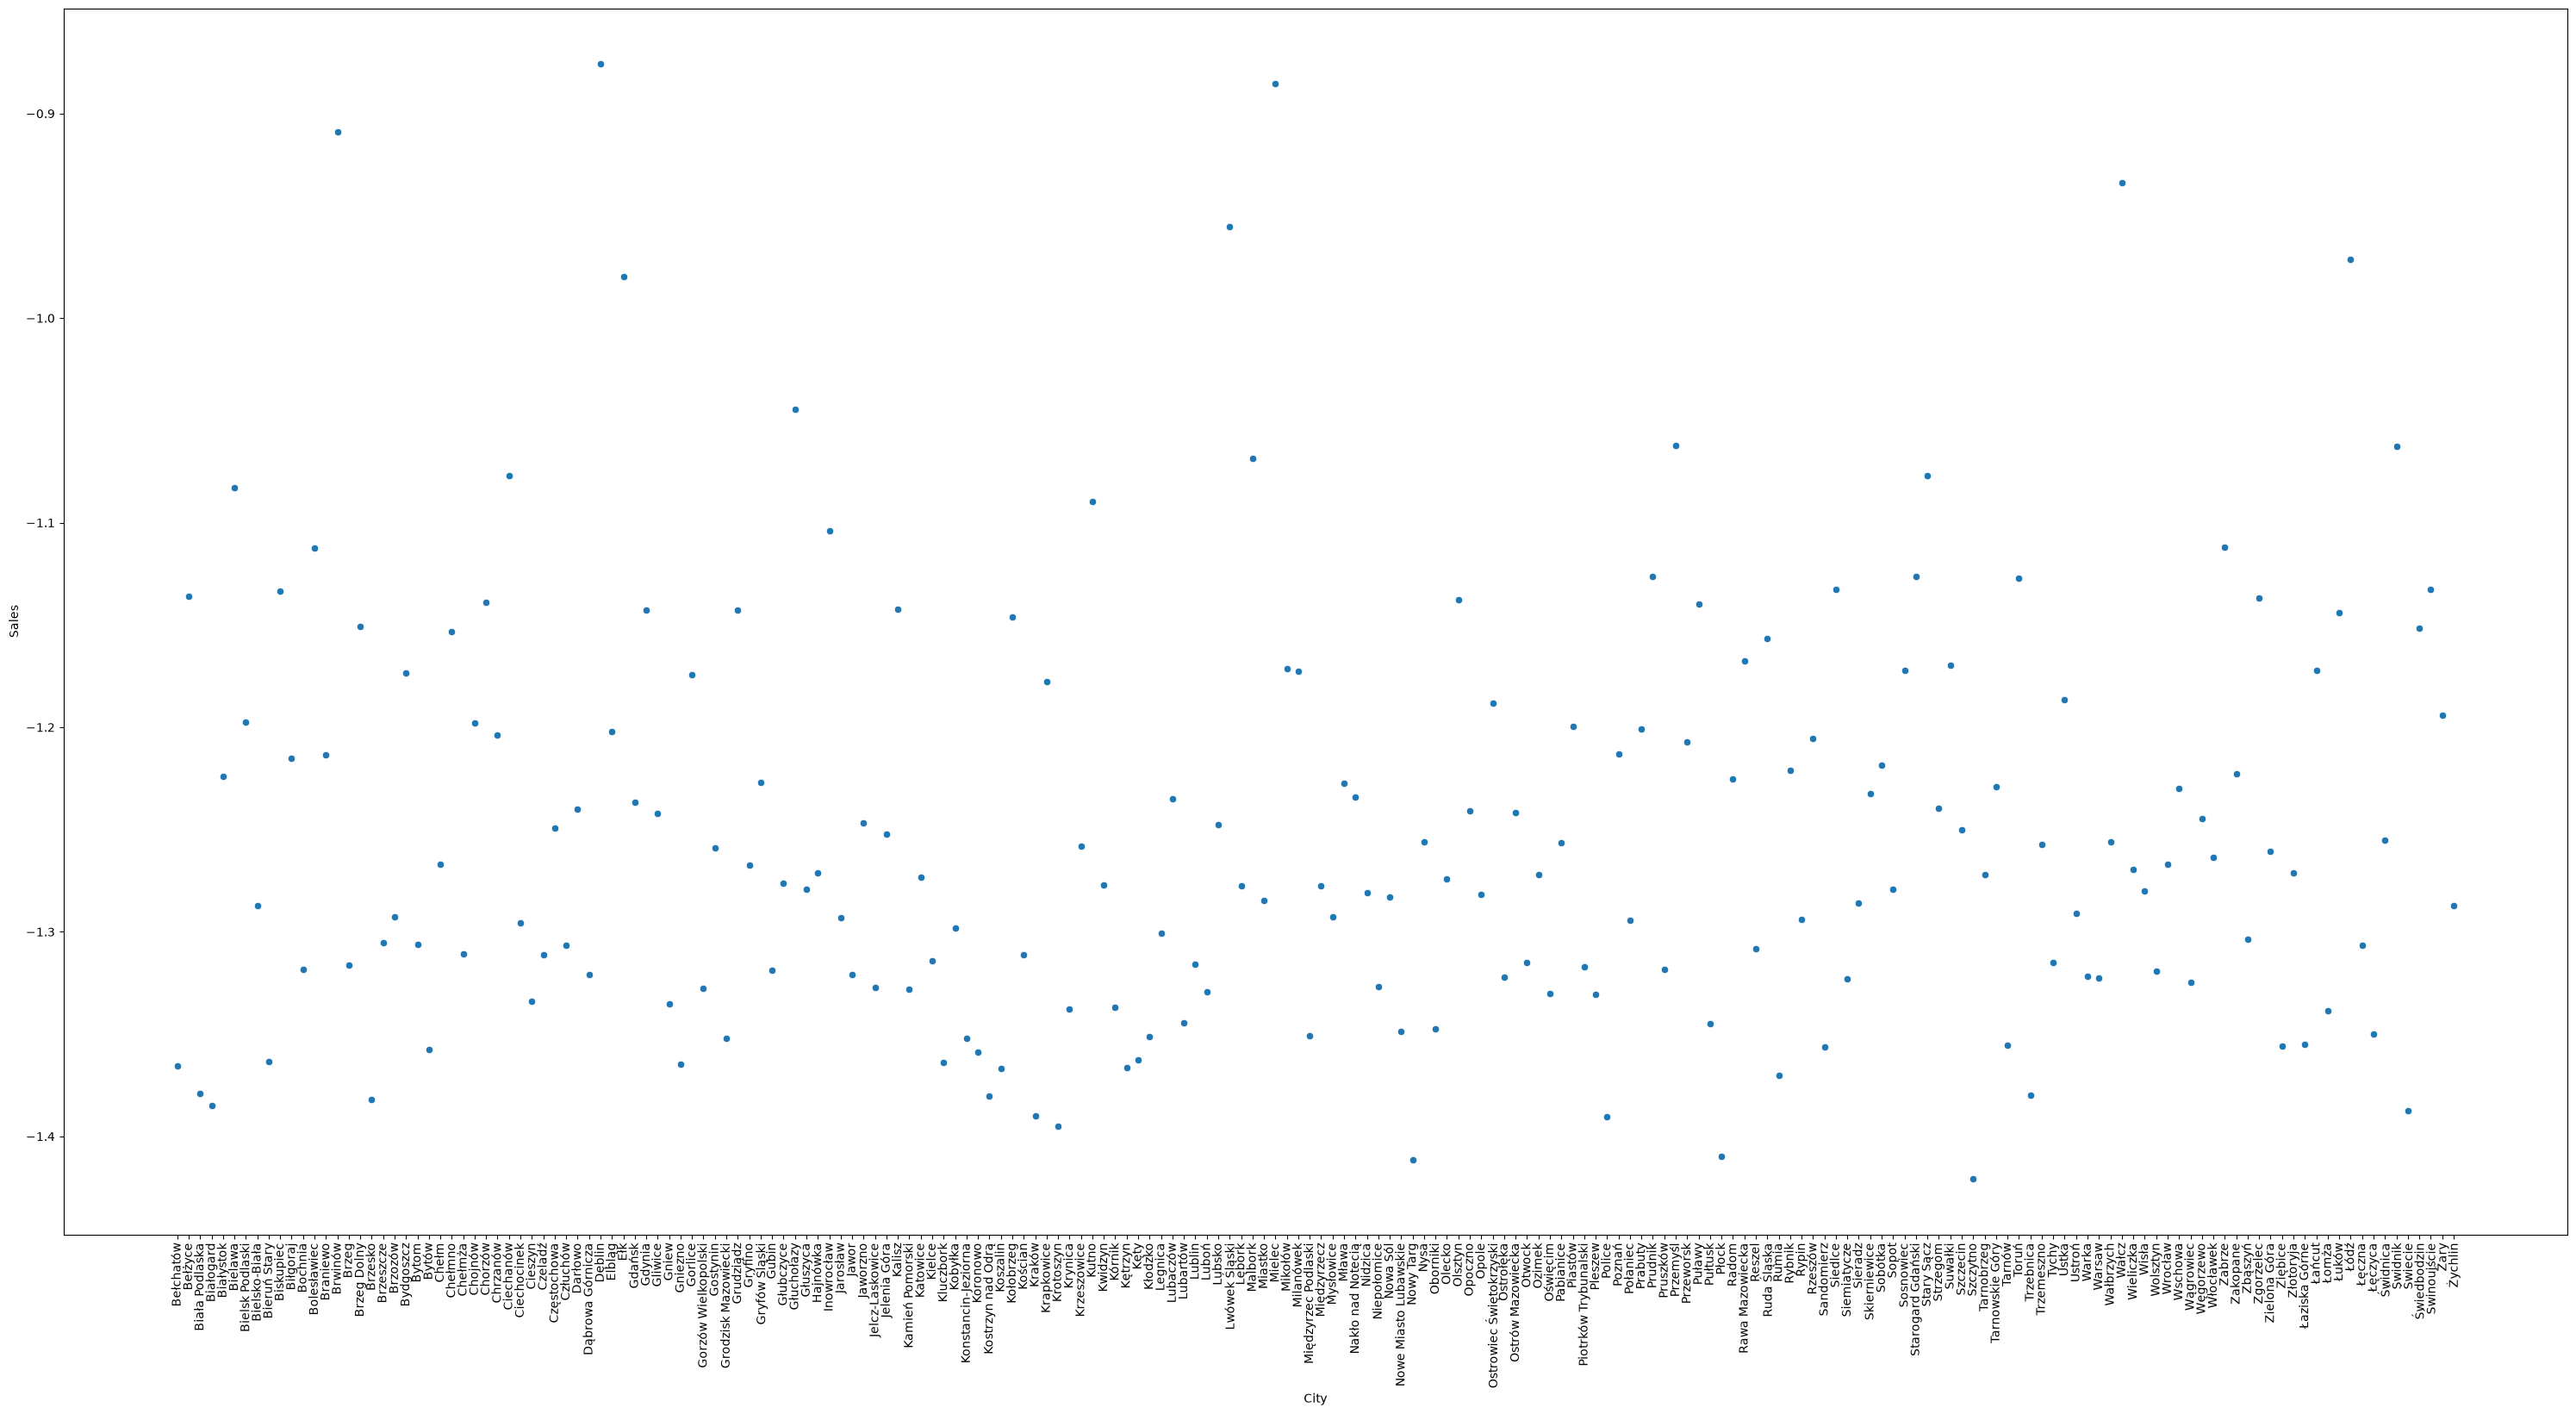

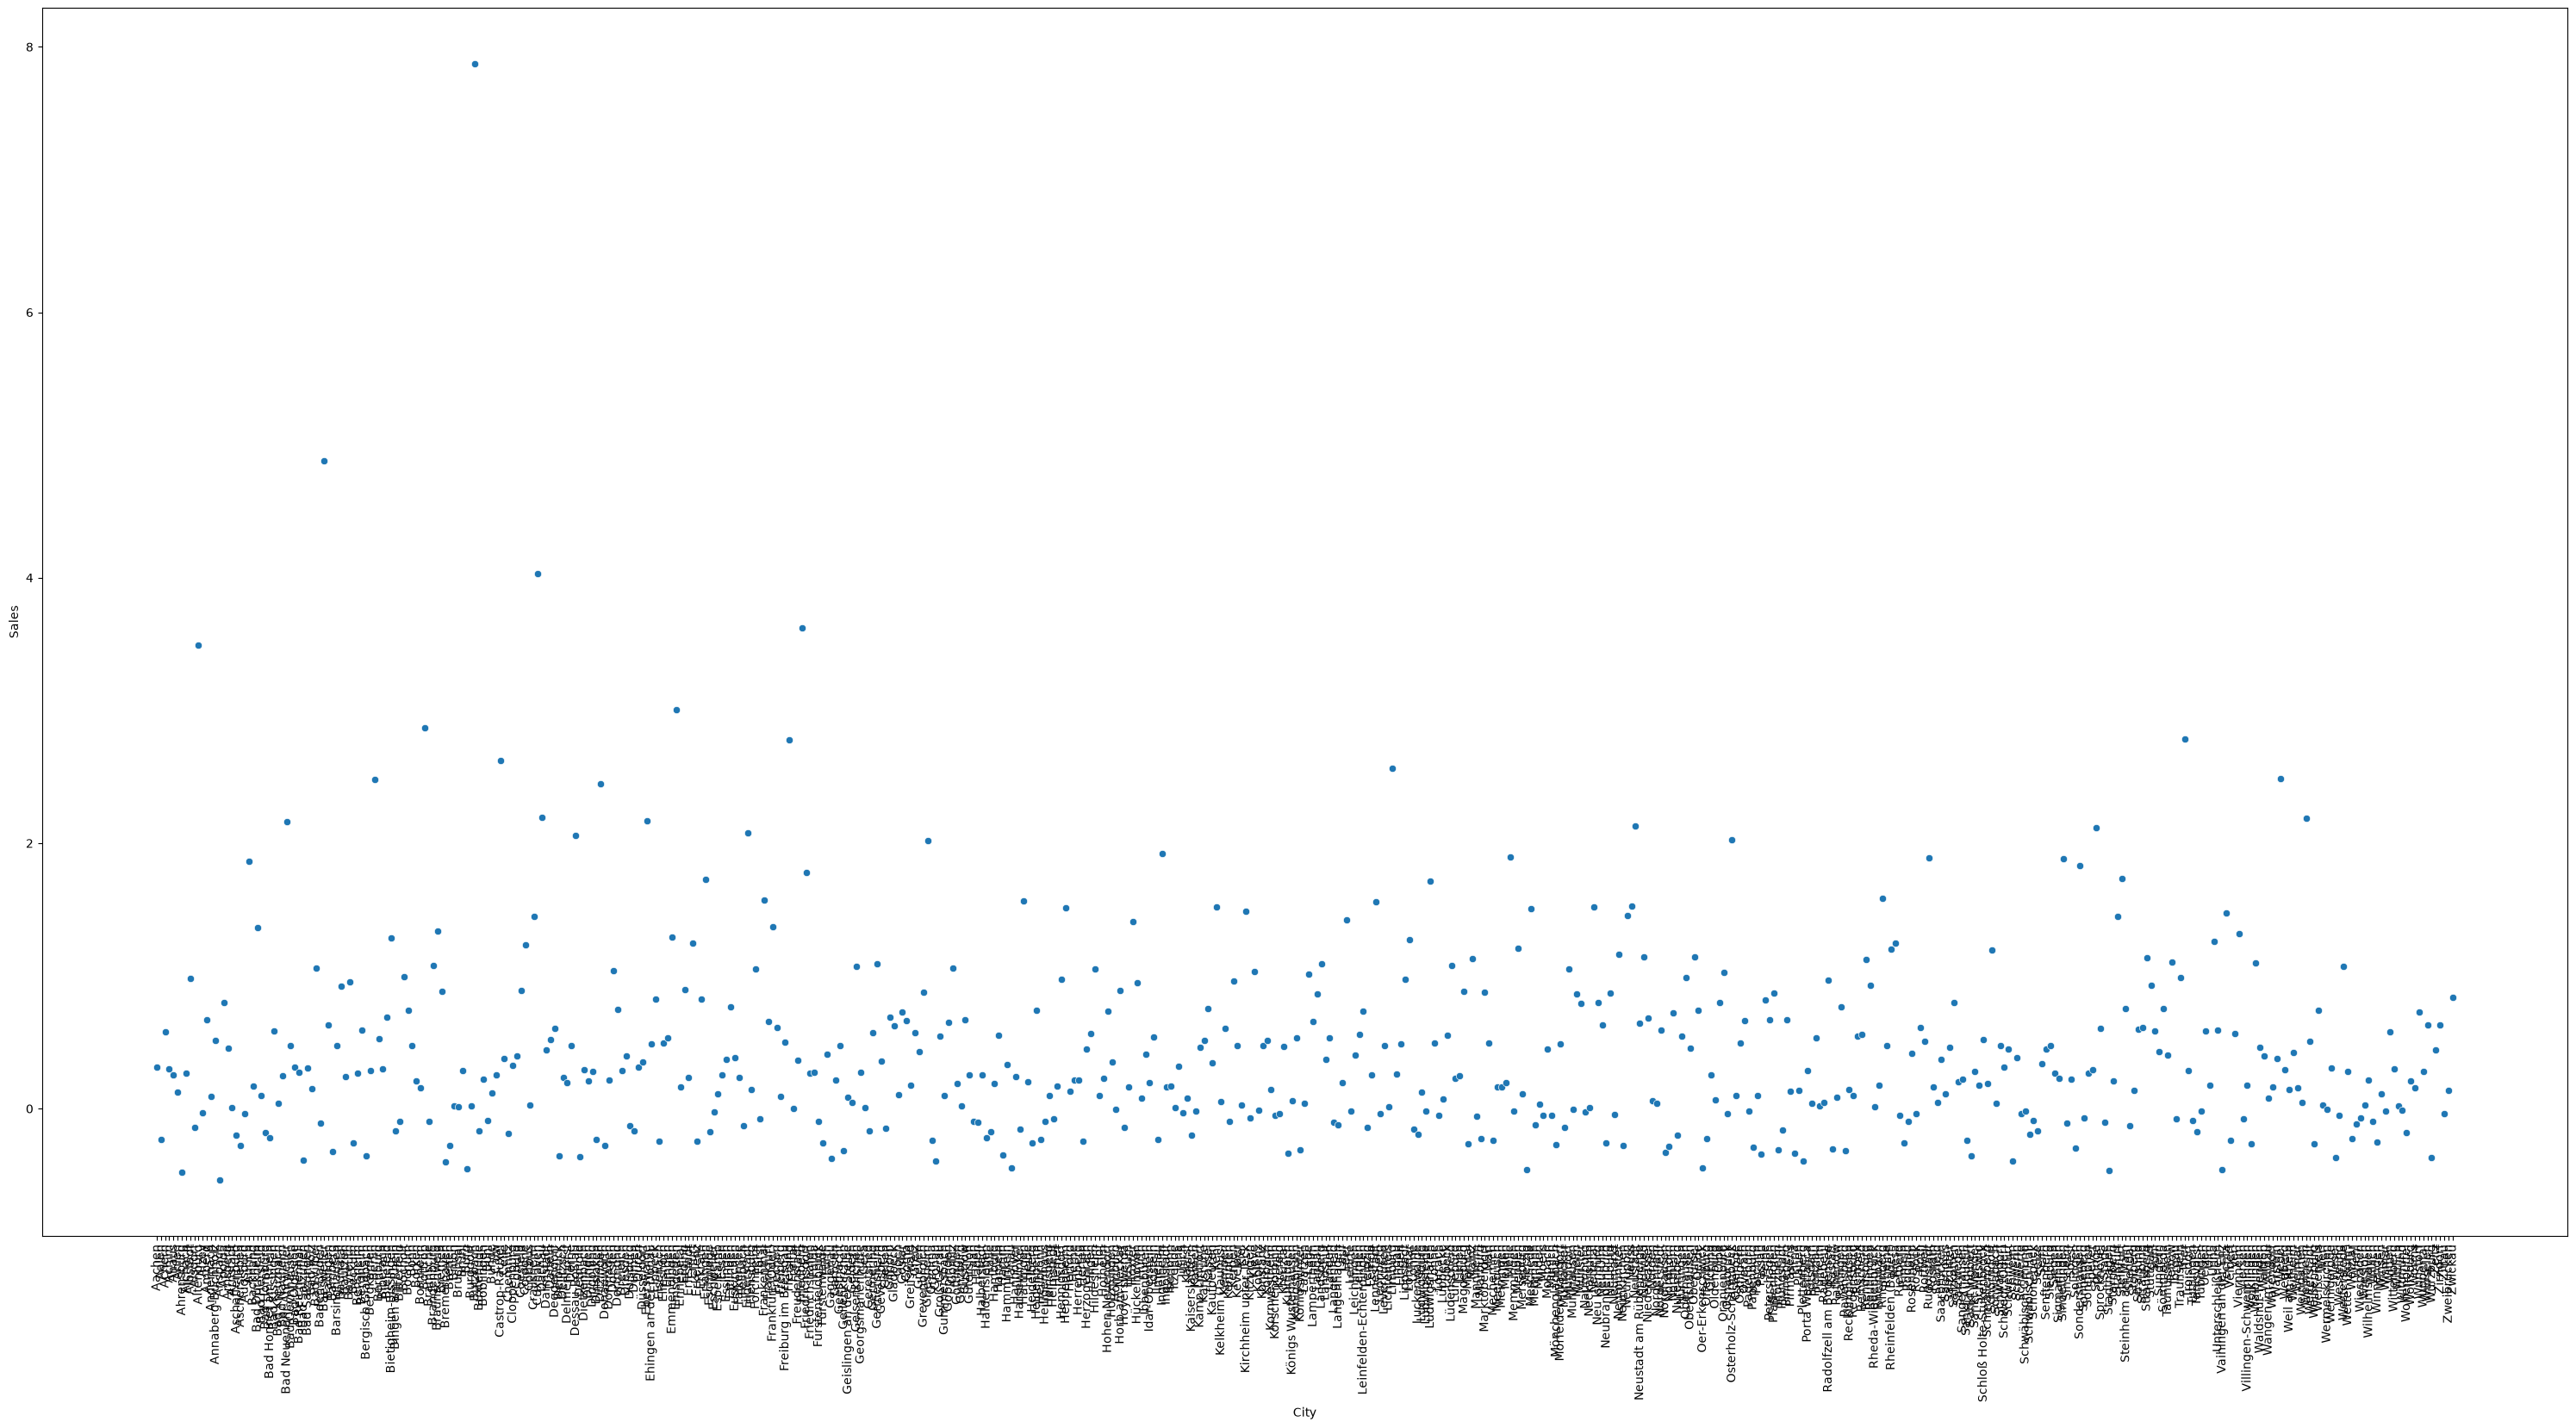

In [56]:

for i in m:
    country_plotted = city_revenue[city_revenue['Country'] == i]

    plt.figure(figsize=(30, 15))
    sns.scatterplot(data = country_plotted, x = 'City', y = 'Sales', legend = False, sizes= (20000, 2000))
    plt.tight_layout() # prevent long city names from  being cut off
    plt.xticks(rotation = 90) # the cities are labelled length wise


plt.show()





3. Product Portfolio & Therapeutic Class Dominance

    - Key Goal: Determine your "blockbuster" product classes versus underperforming lines to highlight core revenue drivers in your presentation.
    - What to look at: Analyze sales volume and revenue contribution segmented by `Product Class` and specific `Product Name`.

In [57]:
product_sales_vol= df.groupby(['Product Class', 'Product Name'])['Sales'].sum()
product_sales_vol = product_sales_vol.reset_index()
product_sales_vol = pd.DataFrame(product_sales_vol)

product_sales_vol

,Product Class,Product Name,Sales
0,Analgesics,Acelimus,8.680605e+07
1,Analgesics,Afaxacin,9.032520e+06
2,Analgesics,Aldevac,3.840590e+06
3,Analgesics,Alemtuvatol Megalinum,6.674325e+07
4,Analgesics,Alglutriptan,3.034501e+07
...,...,...,...
235,Mood Stabilizers,Topitaine,6.637970e+07
236,Mood Stabilizers,Trazobalamin,8.347863e+07
237,Mood Stabilizers,Trazozaprine,8.720082e+07
238,Mood Stabilizers,Veratorol Ciclovatol,1.576544e+07


In [58]:
# check the rnage of the y_axis 
#USE MIN MAX SCALING - NO NEGATIVE SALES VALUE NEEDED 
scaler = MinMaxScaler()
np.ptp(product_sales_vol['Sales']) # 167704508.0 - large value 
y_axis = np.array(product_sales_vol['Sales'])
y_axis_shaped = y_axis.reshape(-1,1)
product_sales_vol['Sales'] = scaler.fit_transform(y_axis_shaped).flatten()
np.ptp(product_sales_vol['Sales']) # 5.754466242085517 - smaller value 

np.float64(1.0)

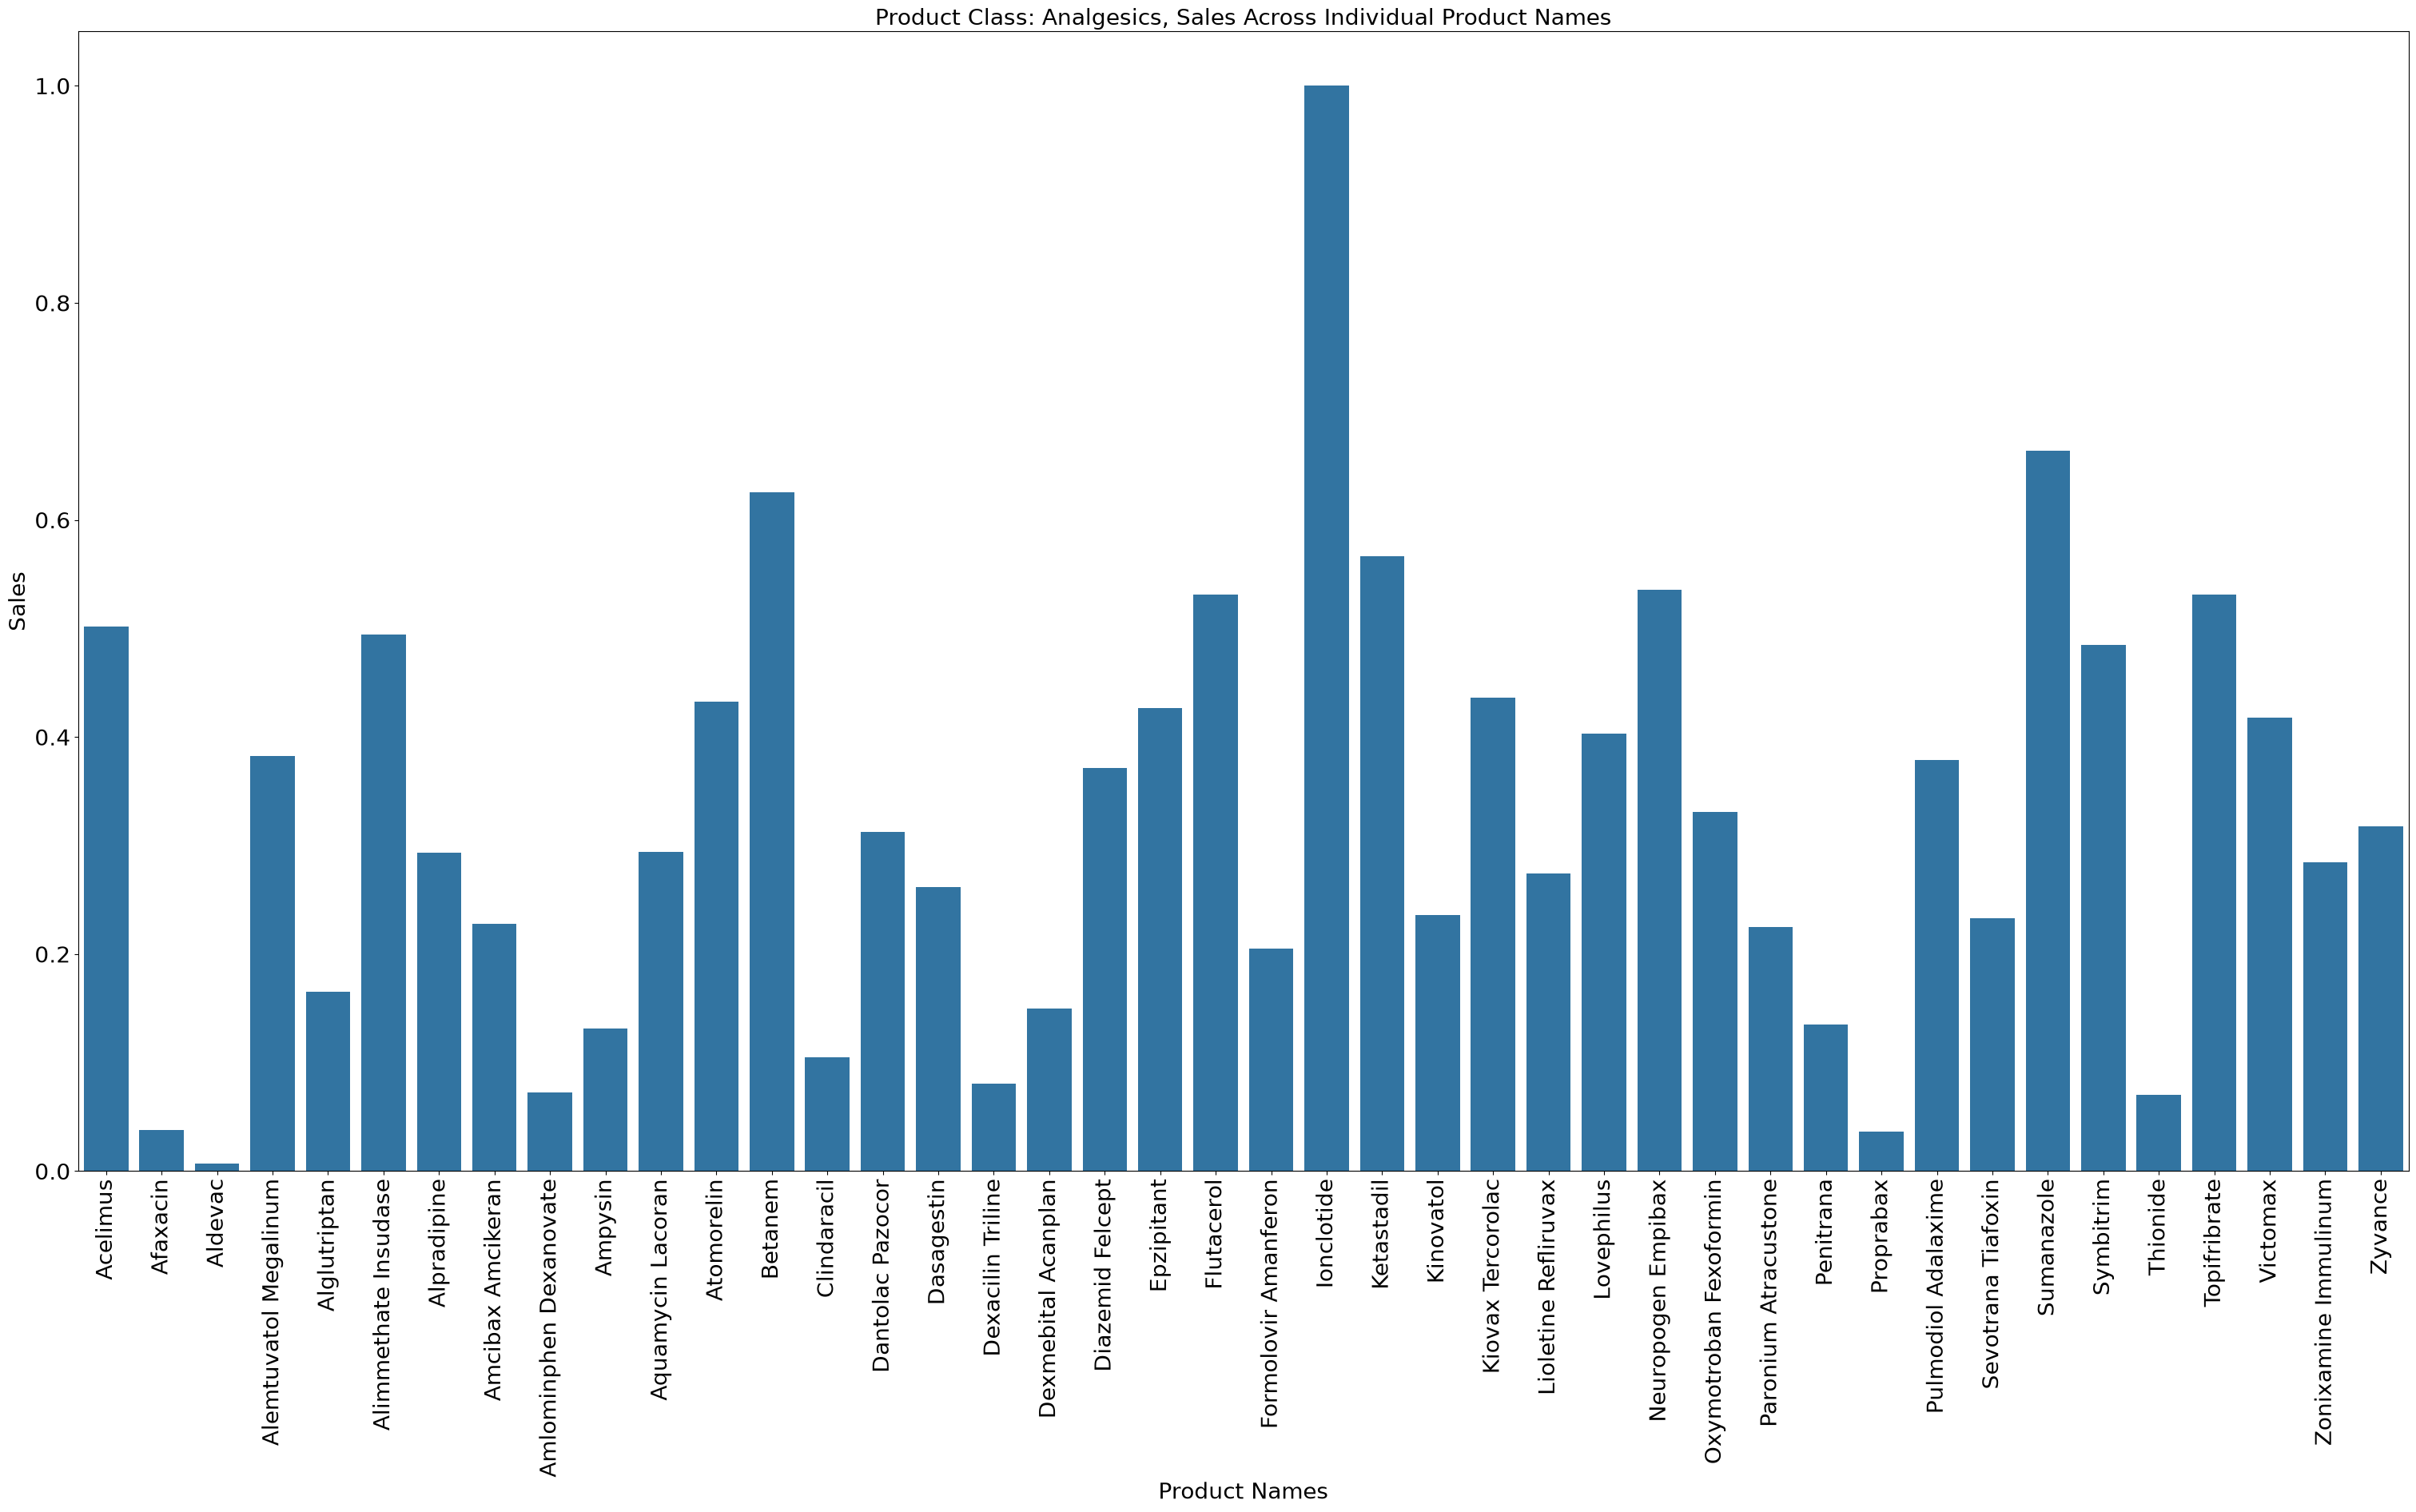

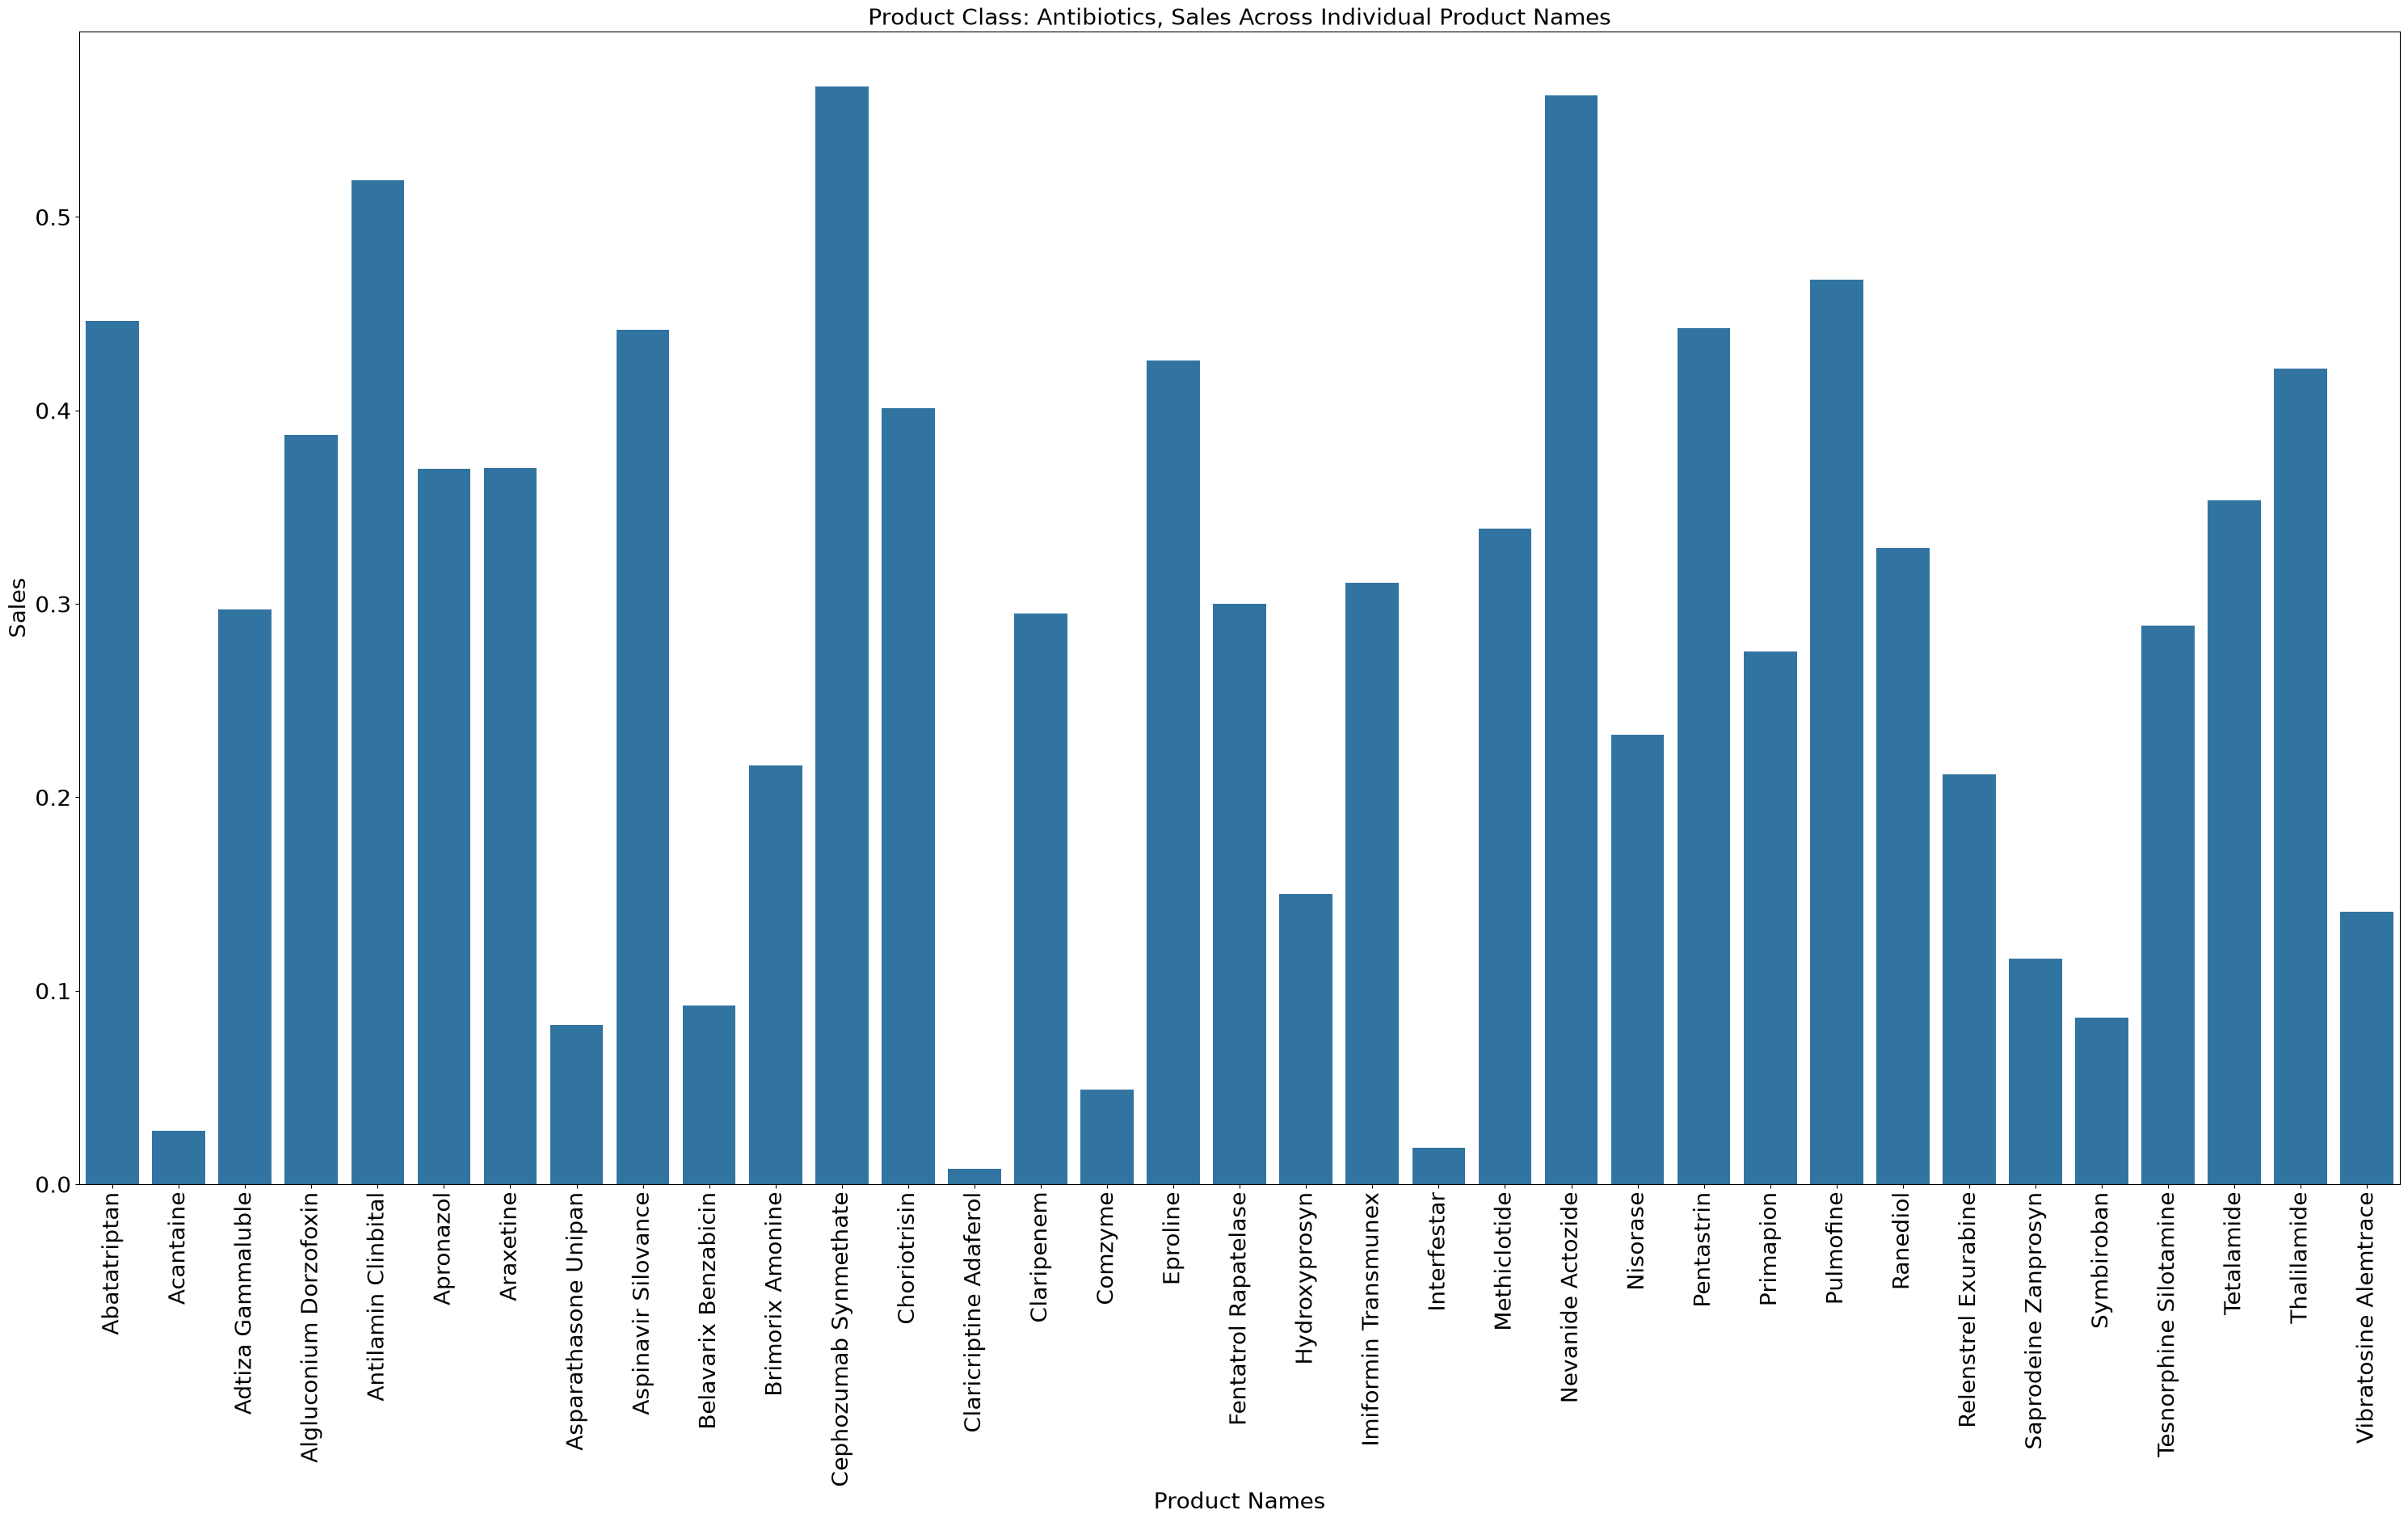

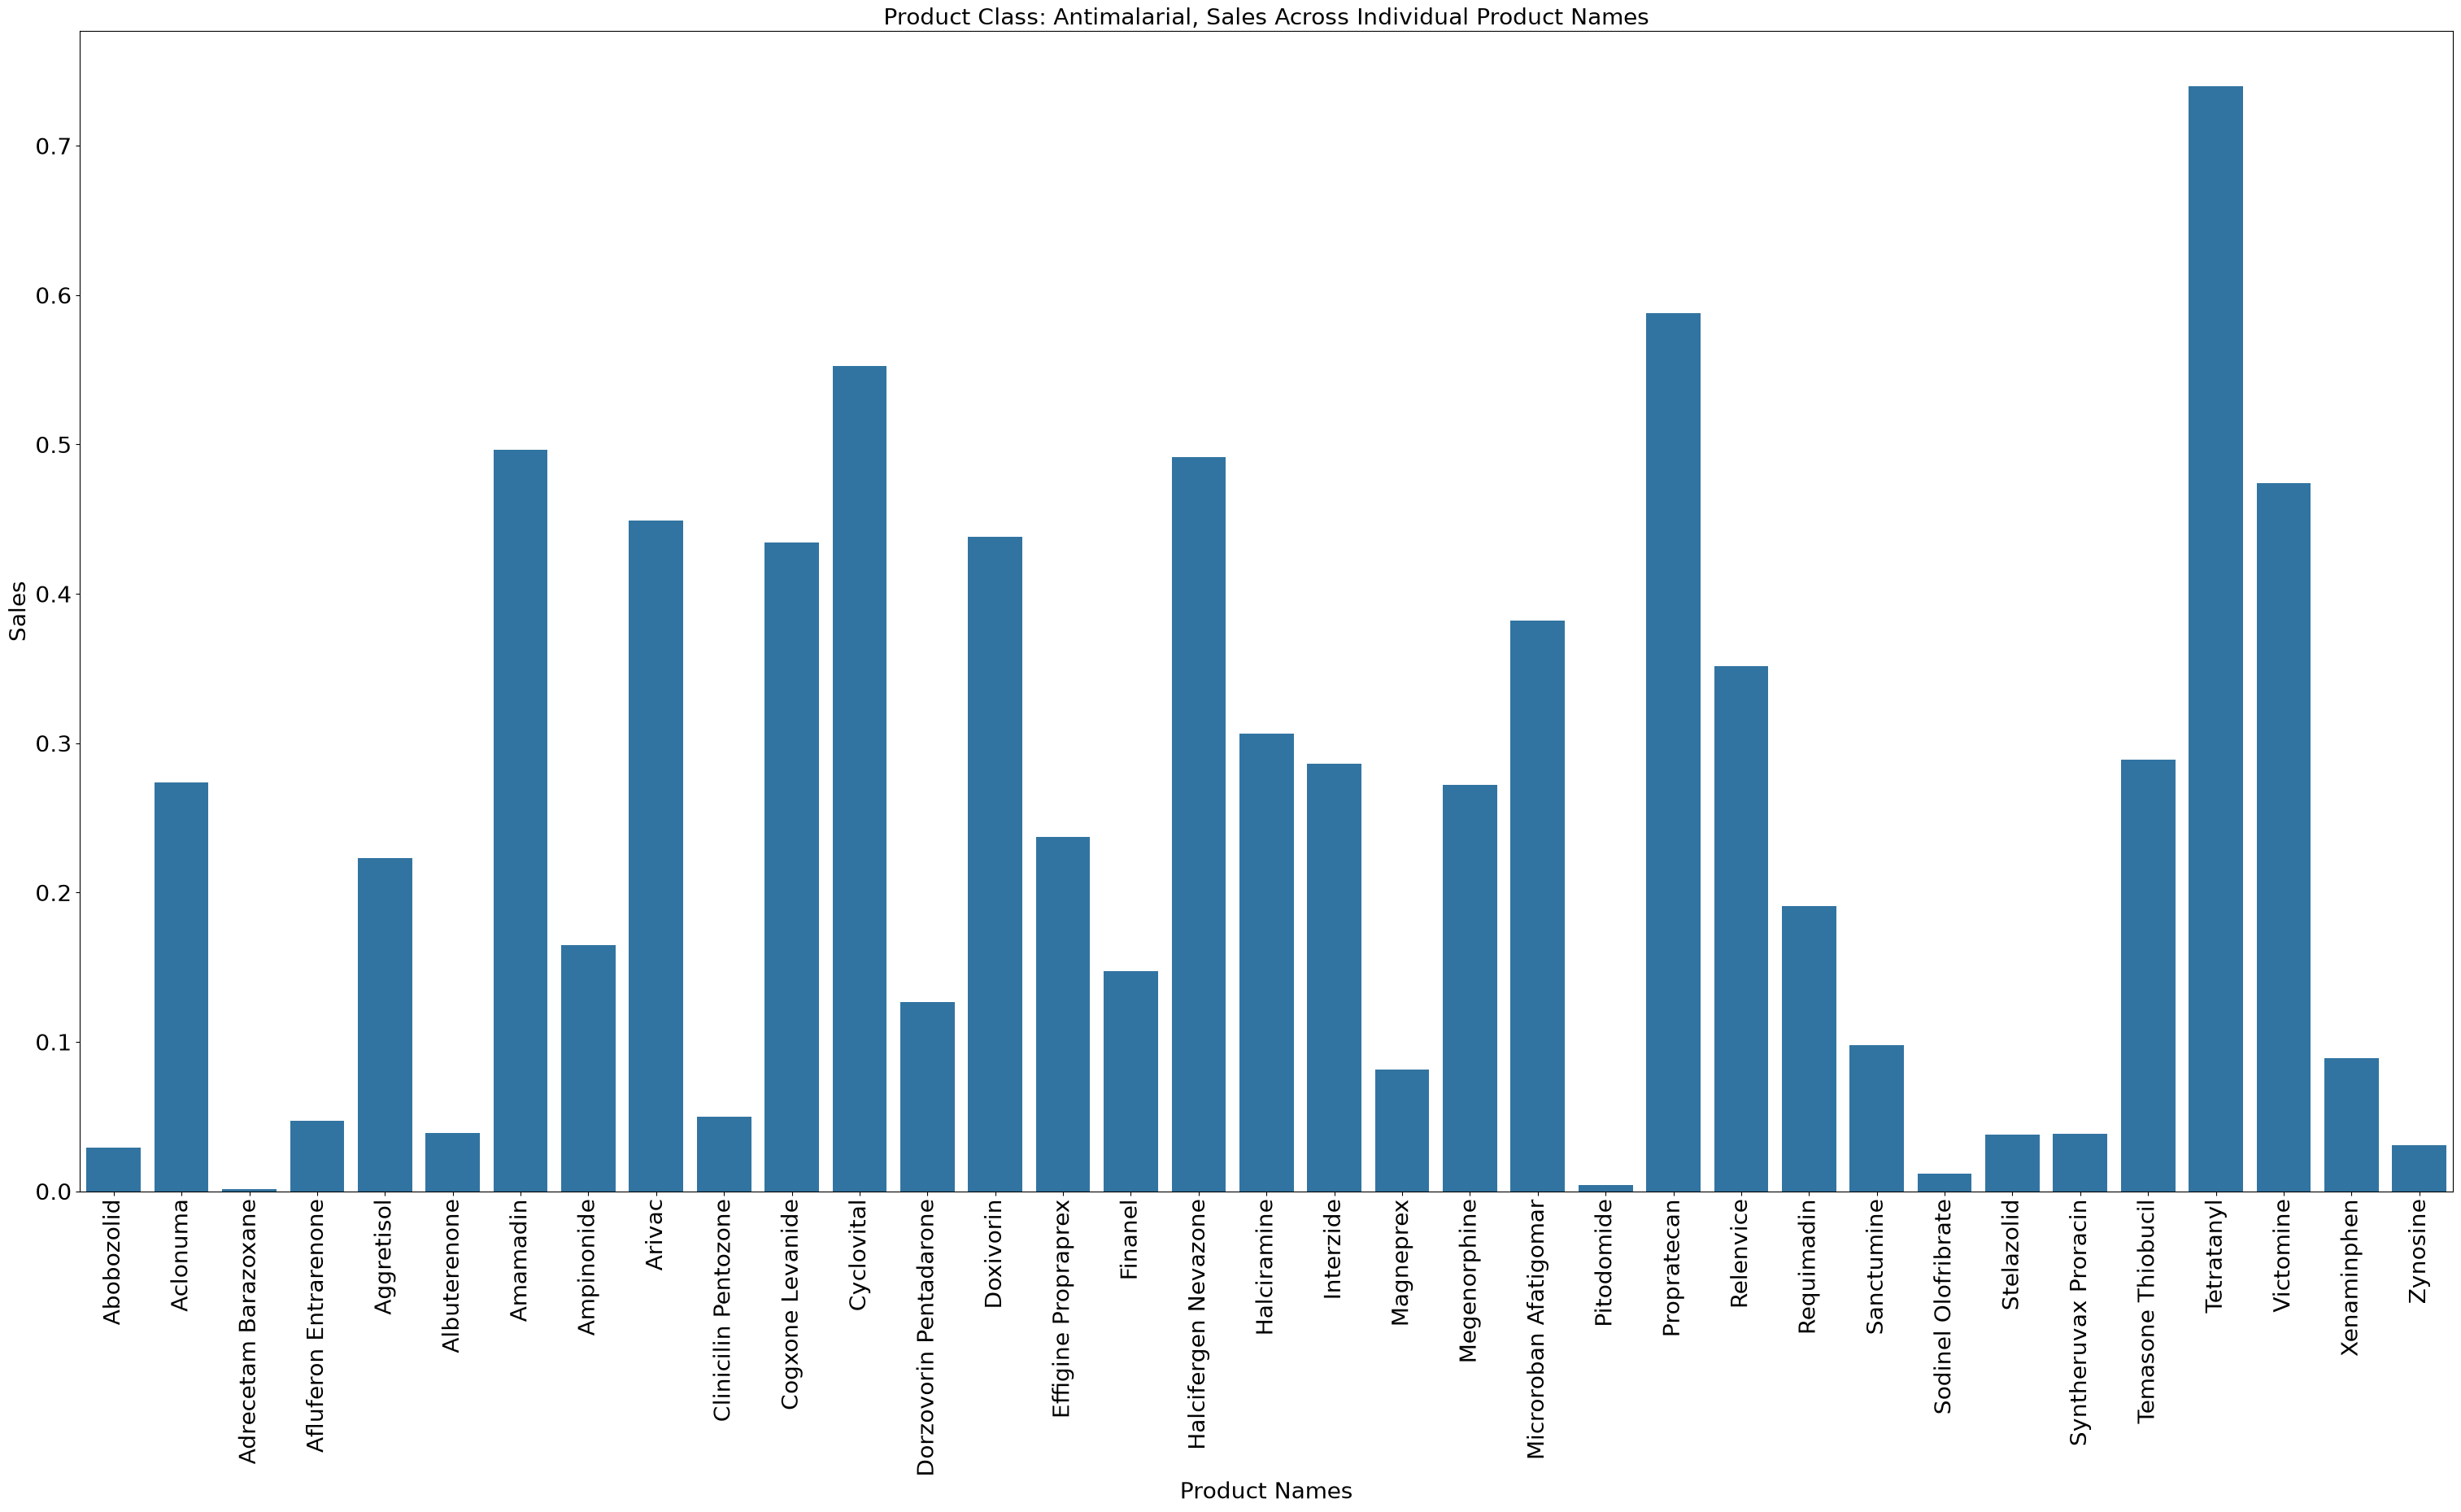

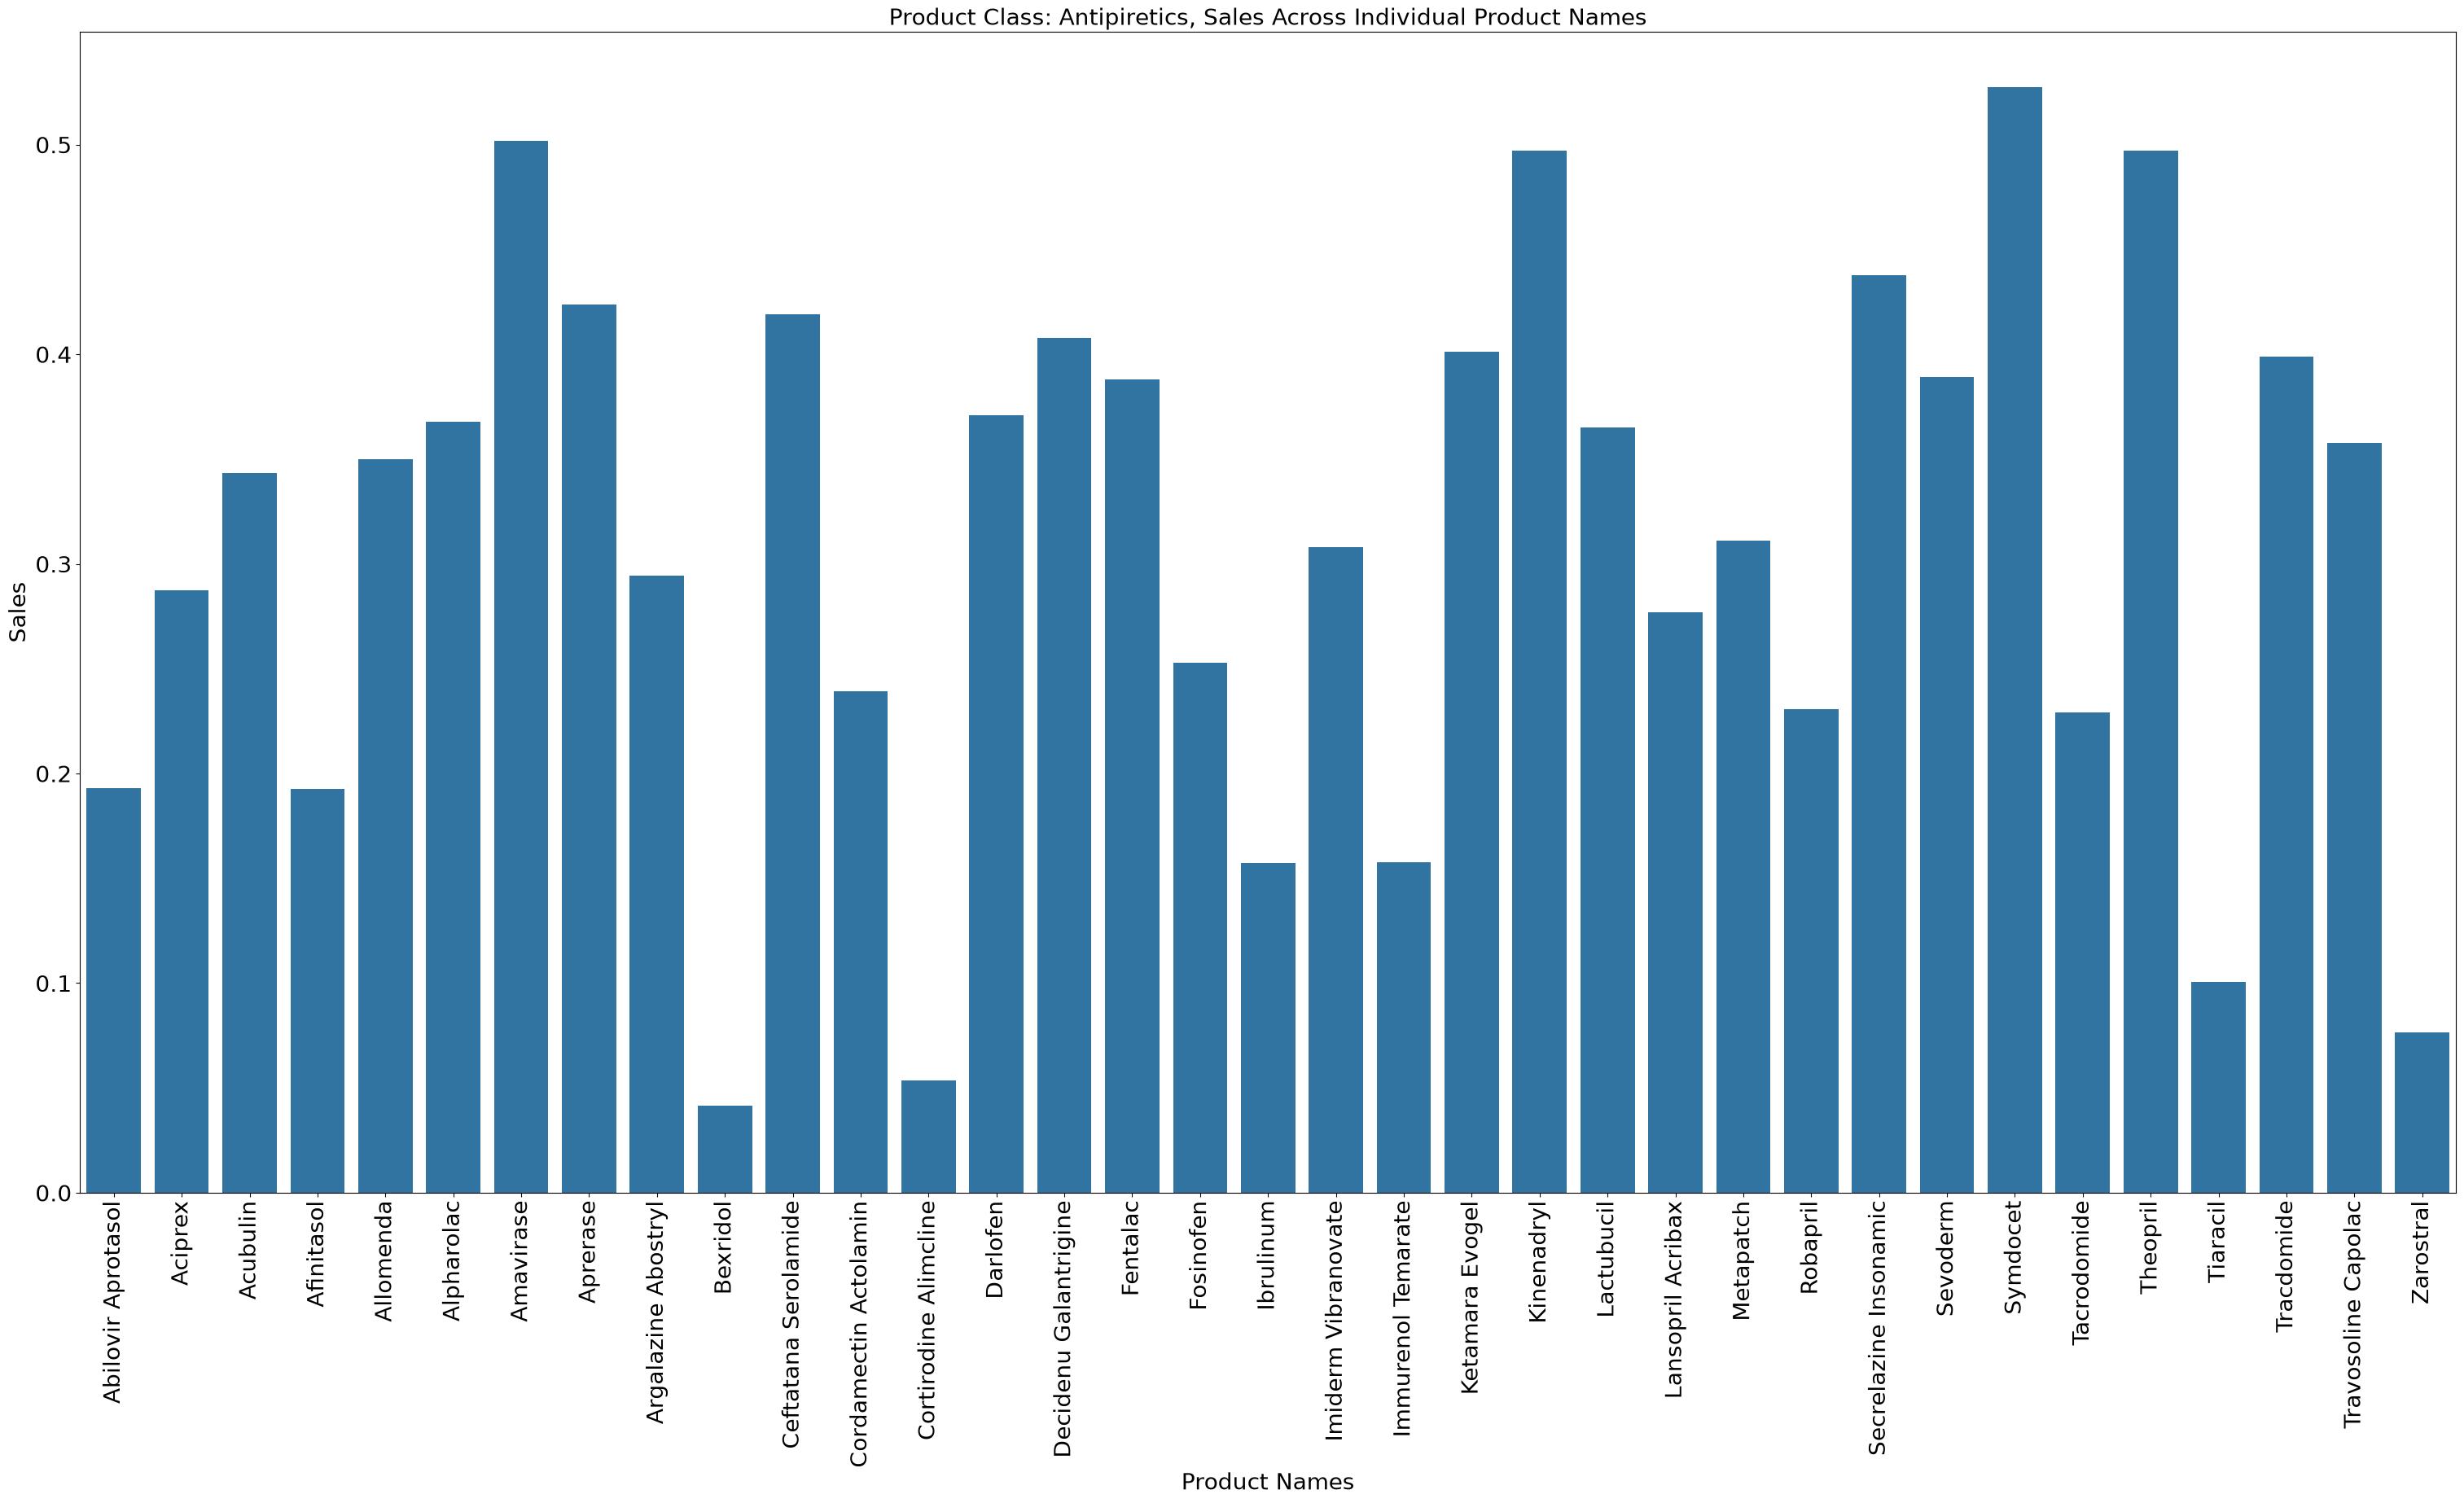

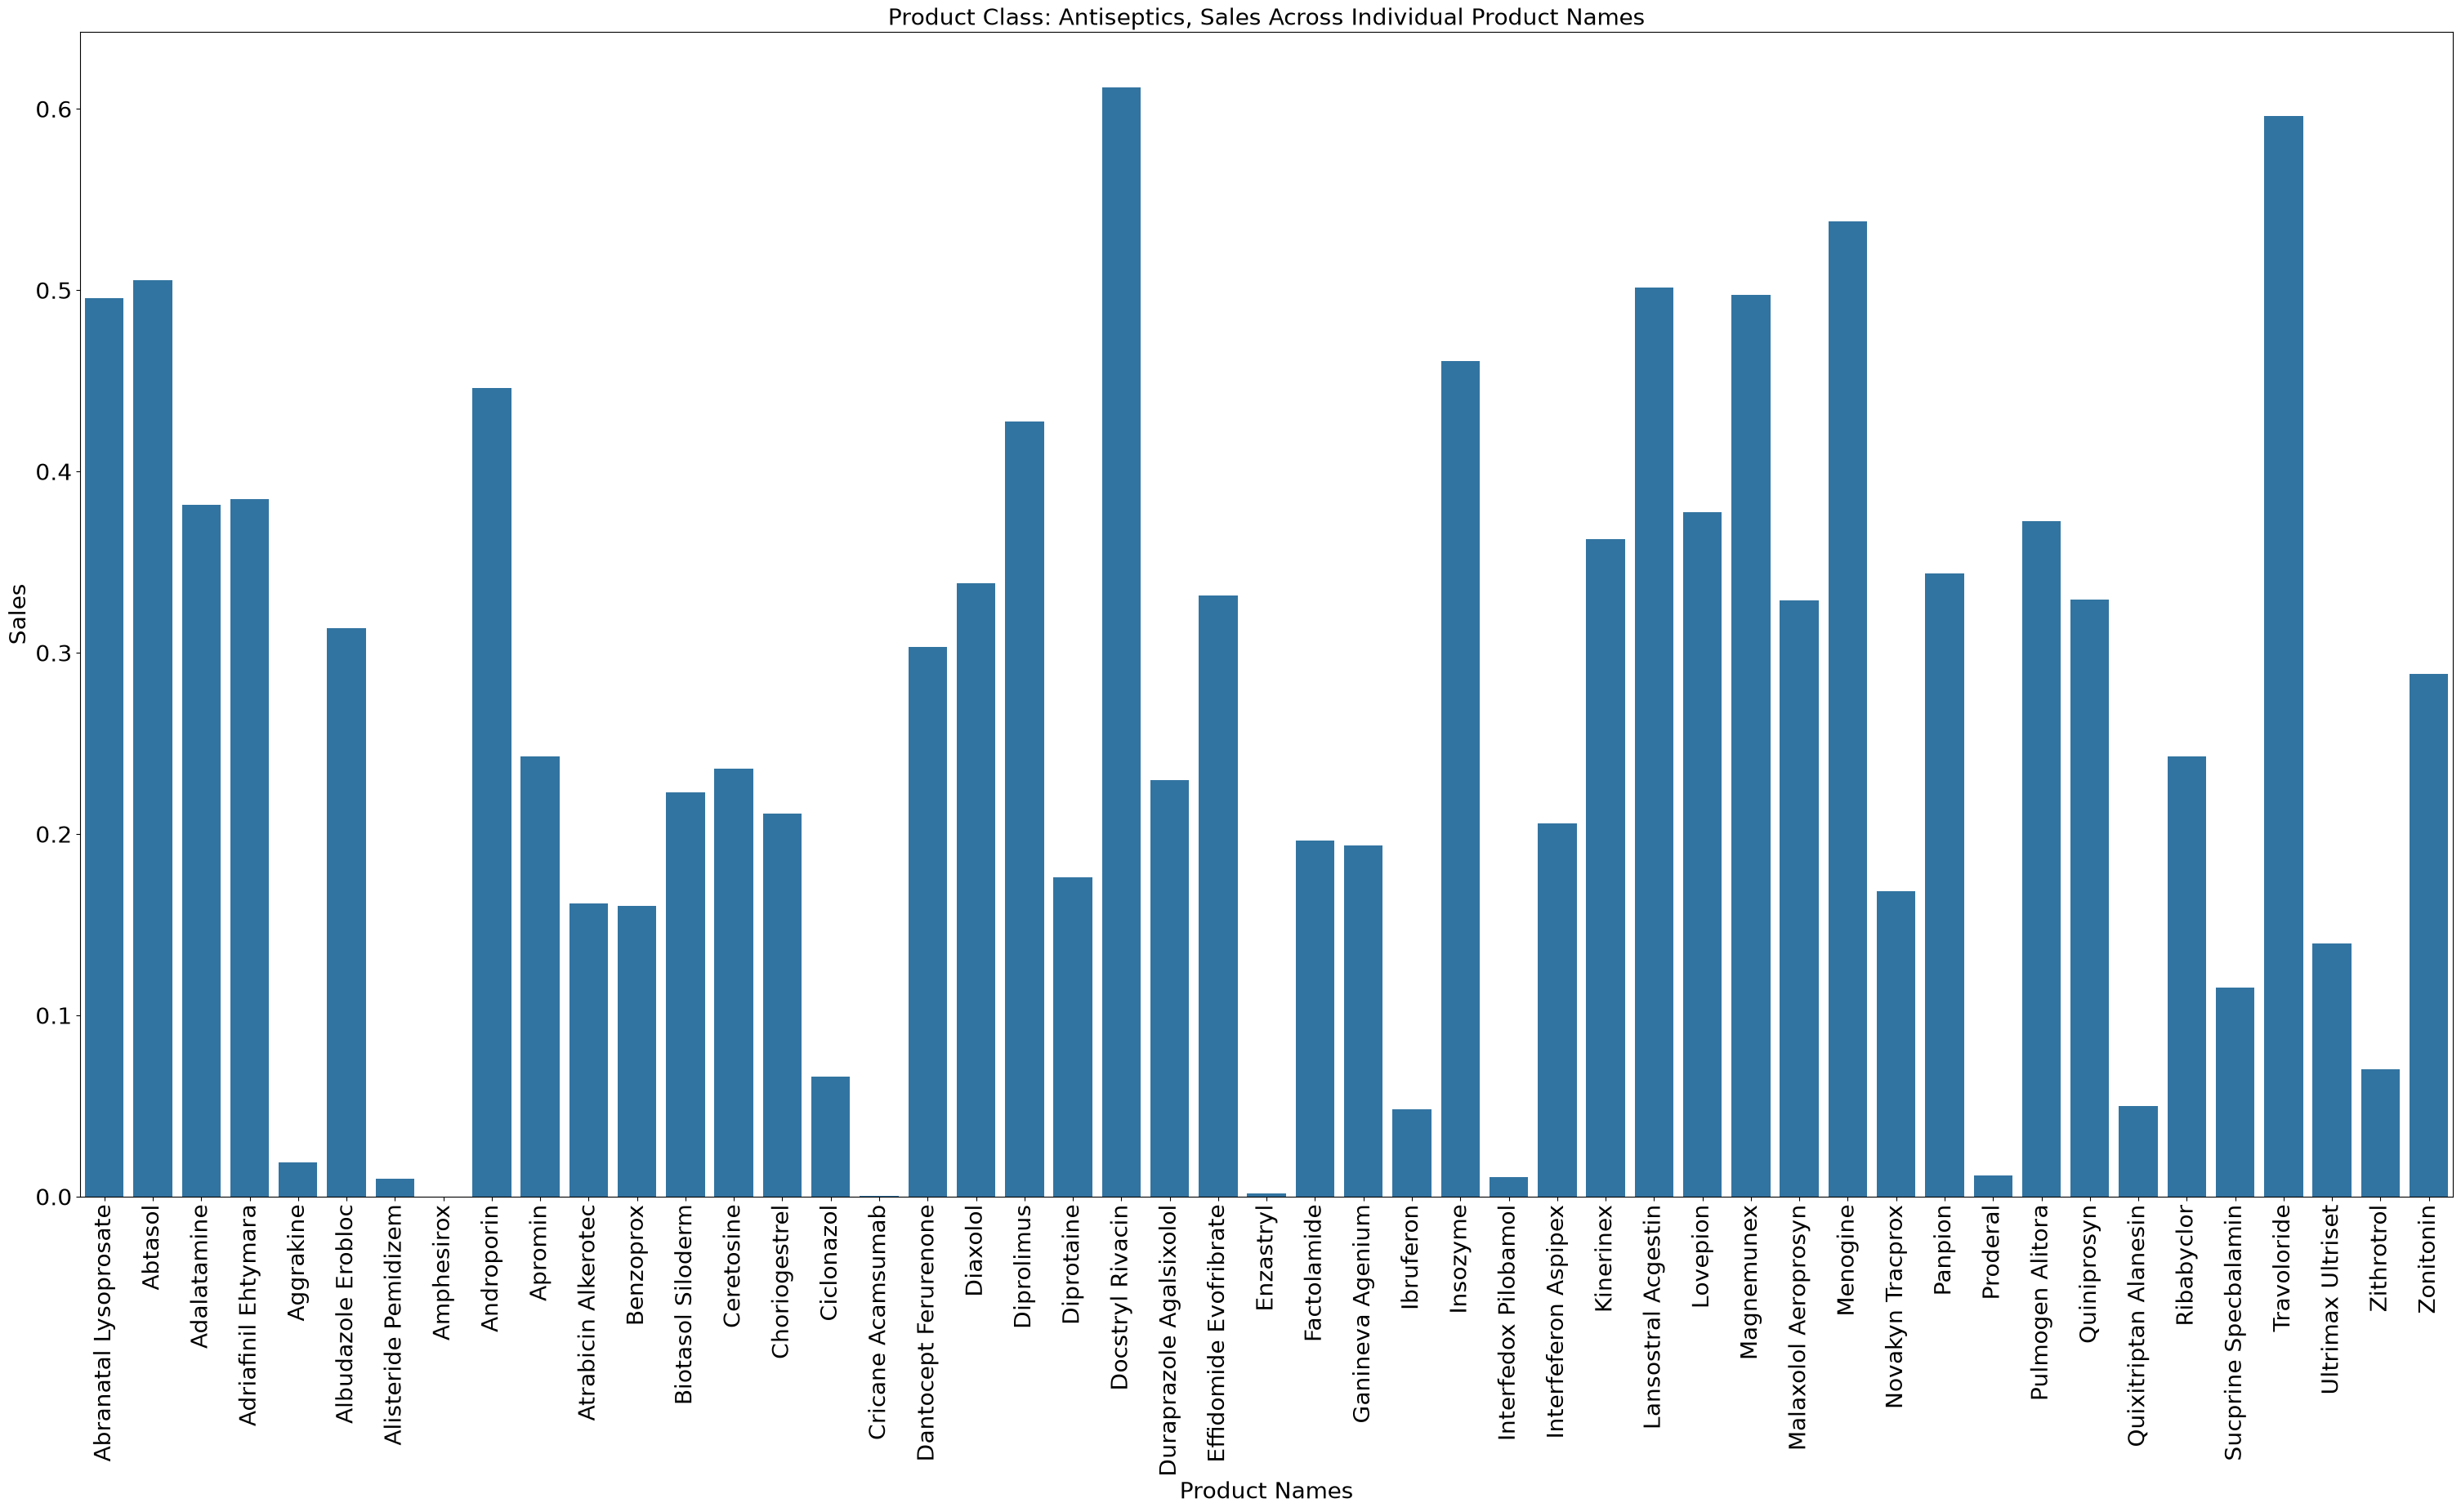

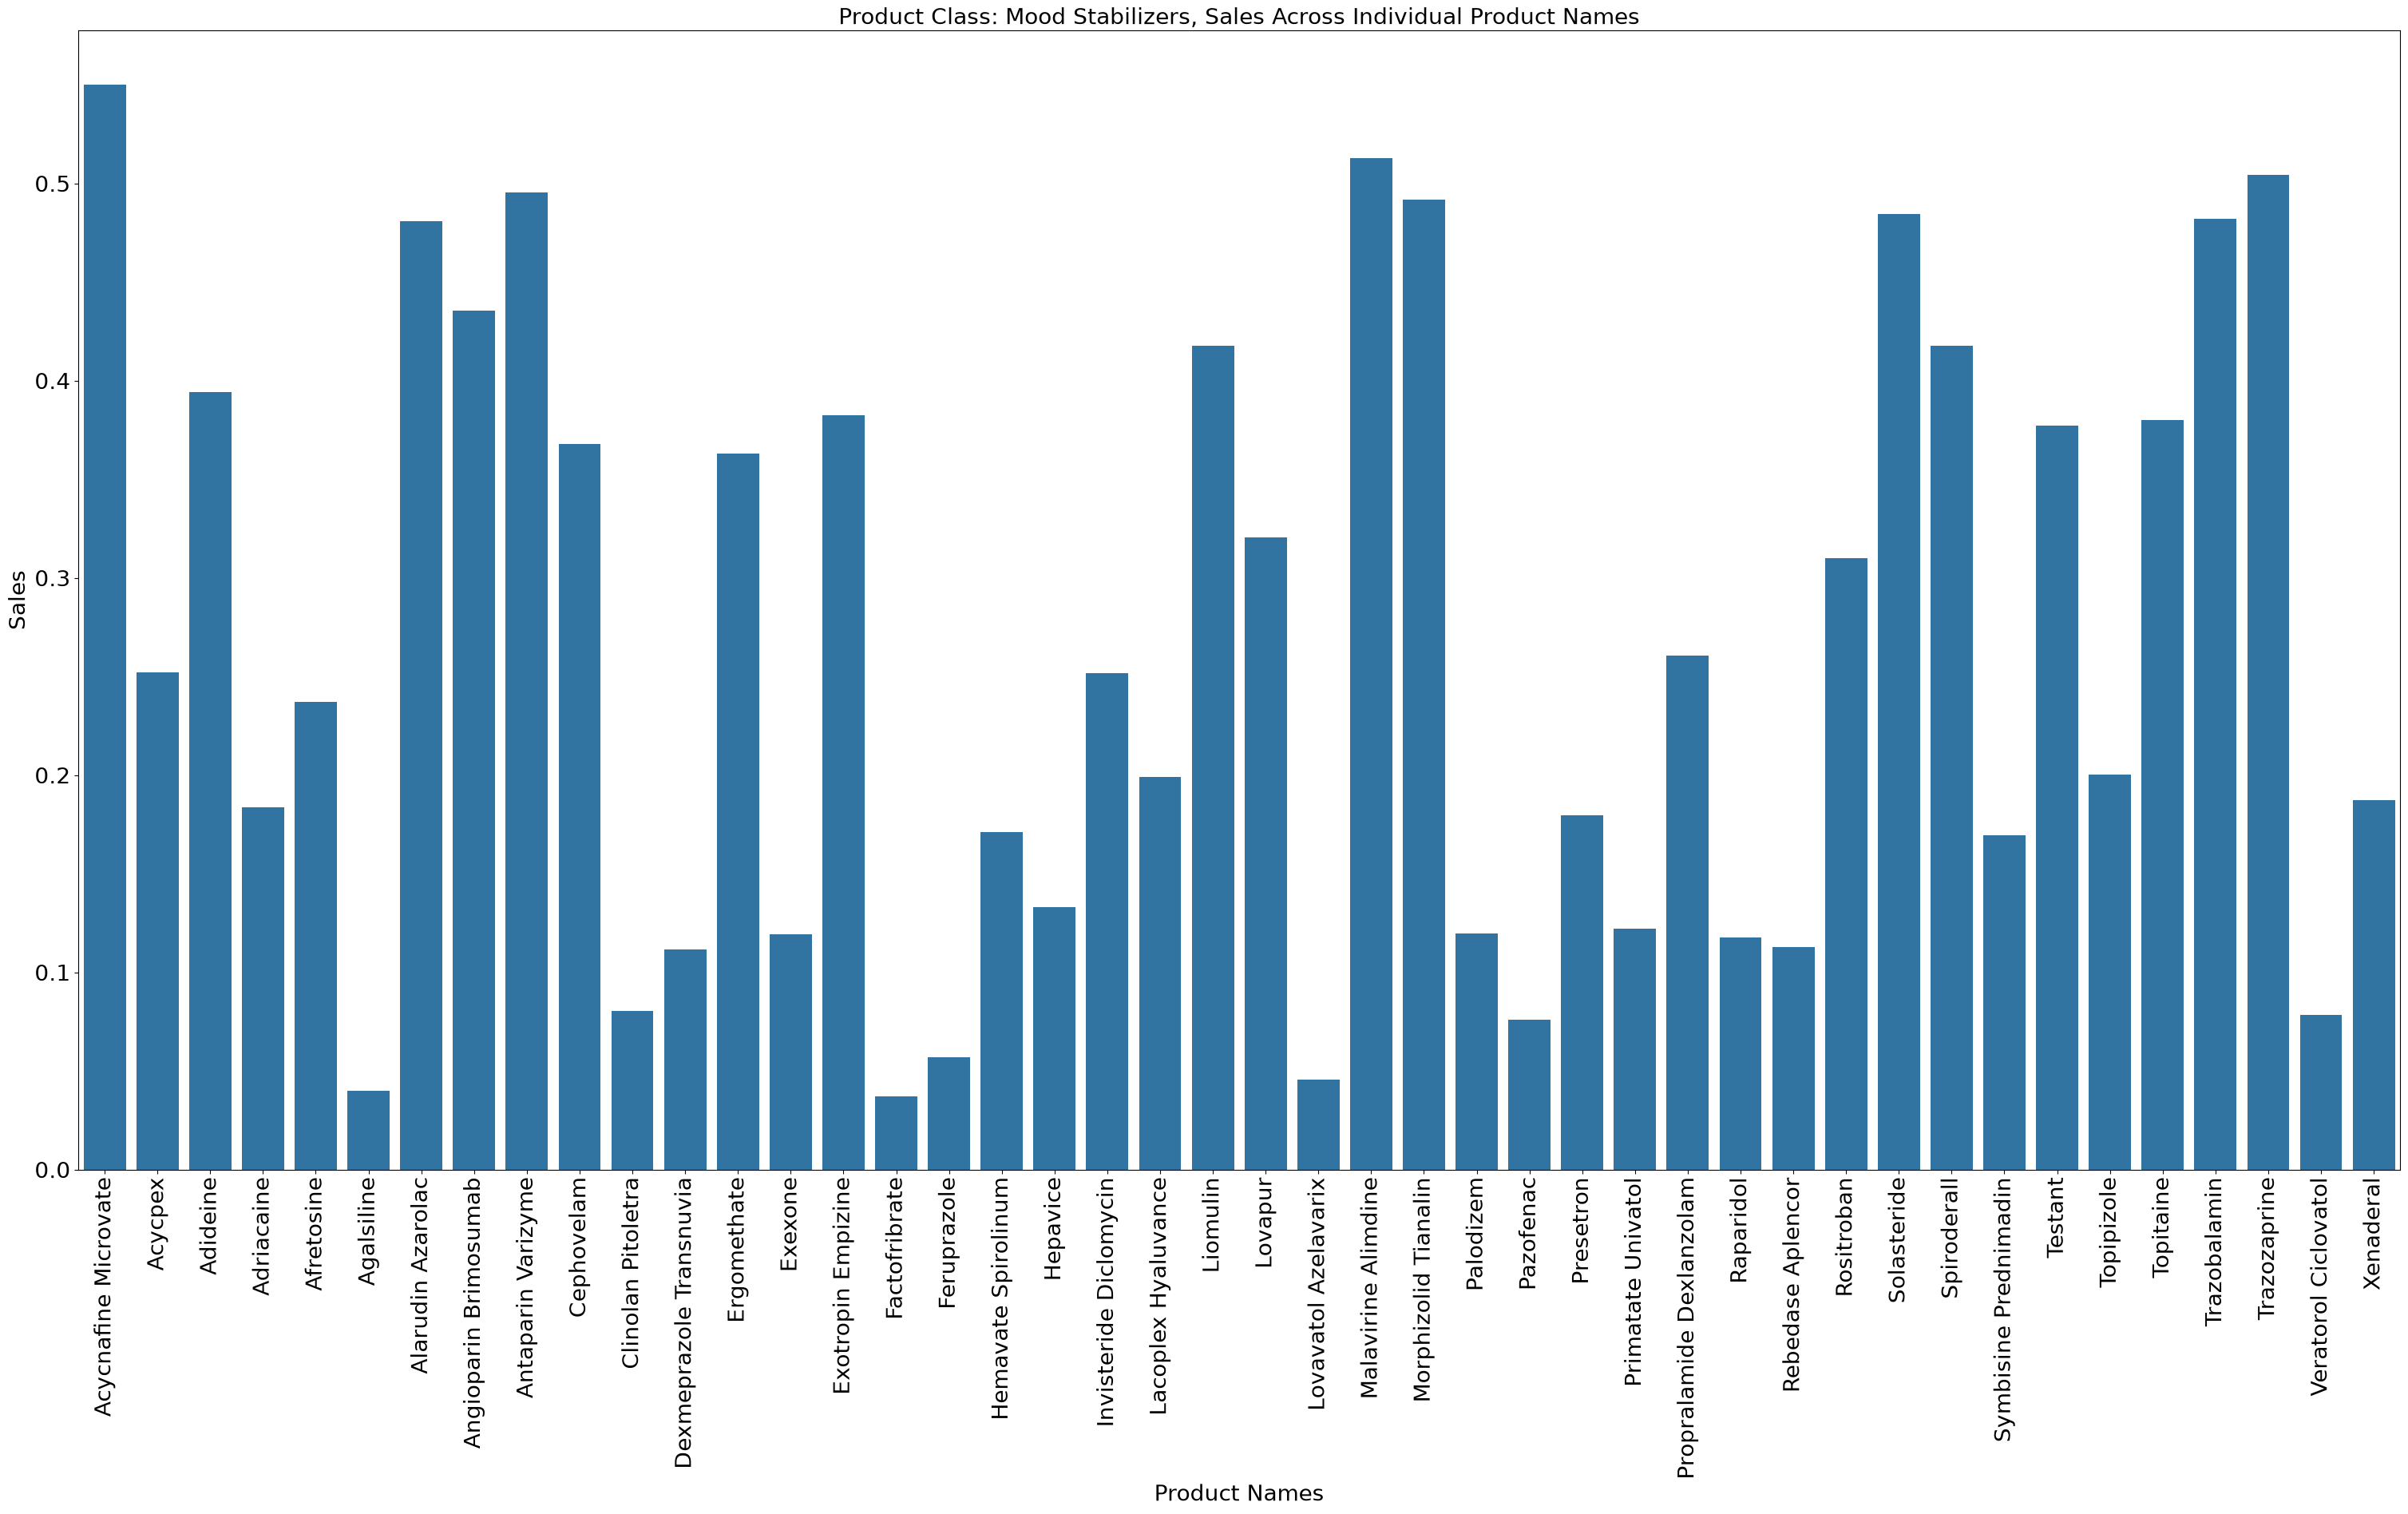

In [ ]:
product_classes = np.array(product_sales_vol['Product Class'].unique())
len(product_classes)
for i in product_classes:
    products_plotted= product_sales_vol[product_sales_vol['Product Class'] == i]

    plt.figure(figsize=(30, 15))
    sns.barplot(data = products_plotted, x = 'Product Name', y = 'Sales', legend = False)
    plt.tight_layout() # prevent long city names from  being cut off
    plt.xticks(rotation = 90, fontsize = 20) # the cities are labelled length wise
    plt.yticks(fontsize = 20)
    plt.title(f"Product Class: {i}, Sales Across Individual Product Names", fontsize=20)
    plt.xlabel('Product Names', fontsize = 20)
    plt.ylabel('Sales', fontsize = 20)
plt.show()



4. Channel & Sub-Channel Efficiency Analysis

    - Key Goal: Evaluate whether institutional sales or retail channels drive higher transaction values and profit margins.
    - What to look at: Compare performance metrics between `Channel` (e.g., Hospital vs. Pharmacy) and `Sub-channel` (e.g., Private, Retail, Institution).

In [ ]:
# profit margins - sales differences
# group by channels, observe subchannel sales discrepencies 
# average transaction value (retail)
#ATV = Total Revenue / Total Number of Transaction 
sc_annual_transactions = df.groupby(['Year', 'Sub-channel'])['Sales'].size()
sc_annual_transactions = pd.DataFrame(sc_annual_transactions)
sc_annual_transactions = sc_annual_transactions.reset_index()

#to Calculate the total number of transactions per subchannel over each year :
sc_annual_transactions = sc_annual_transactions.rename(columns = {'Sales': 'transactions'})

sc_annual_sales = df.groupby(['Year', 'Sub-channel'])['Sales'].sum()

sc_annual_sales = sc_annual_sales.reset_index()
sc_annual_sales = pd.DataFrame(sc_annual_sales)

# sc_annual_sales & sc_annual_transactinos have the same order for years and subchannel sorting so now find the corresponing Transaction Value 
# average Transaction Value 
atv = sc_annual_sales['Sales'] / sc_annual_transactions['transactions']

sc_annual_total = sc_annual_transactions.copy()
sc_annual_total['sales'] = sc_annual_sales['Sales']
sc_annual_total['atv'] = atv # average Transaction Value 
sc_annual_total = sc_annual_total.sort_values('Sub-channel')

,Year,Sub-channel,transactions,sales,atv
0,2017,Government,14933,7.051216e+08,47219.021362
4,2018,Government,23040,8.461936e+08,36727.154557
8,2019,Government,13626,8.162623e+08,59904.762142
12,2020,Government,13324,7.273540e+08,54589.765911
1,2017,Institution,13598,7.052351e+08,51863.147375
5,2018,Institution,22240,8.561912e+08,38497.807059
9,2019,Institution,12674,7.042688e+08,55568.000023
13,2020,Institution,12459,6.487655e+08,52072.034915
2,2017,Private,12186,5.546615e+08,45516.287404
6,2018,Private,23822,8.605419e+08,36123.831836


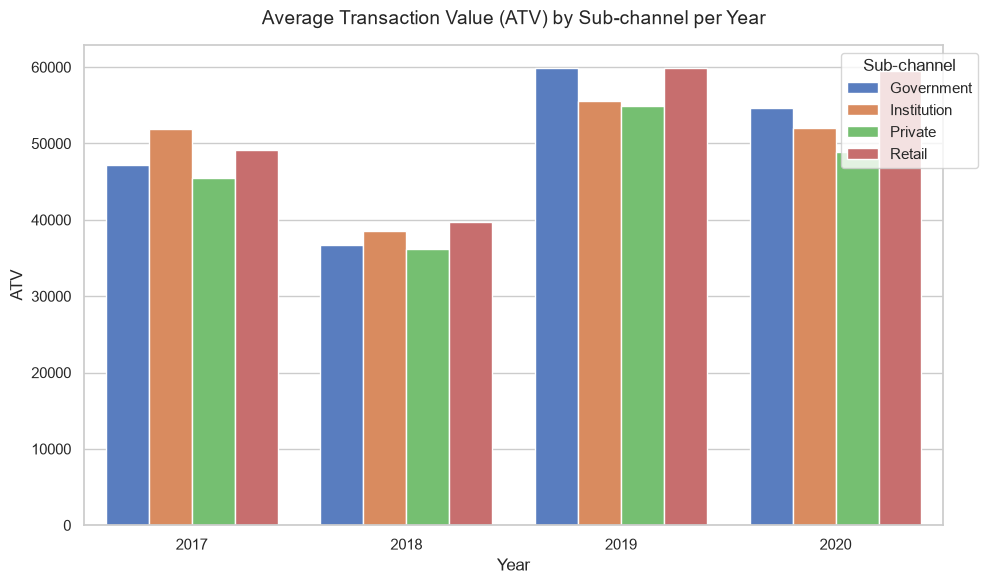

In [89]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=sc_annual_total , 
    x='Year', 
    y='atv', 
    hue='Sub-channel', # hue = which column to use for splitting the bars and by what color 
    palette='muted'
)

plt.title('Average Transaction Value (ATV) by Sub-channel per Year', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('ATV', fontsize=12)
plt.legend(title='Sub-channel', bbox_to_anchor = (1.05, 1), loc='upper right') # moves the chart legend completely outside the main plot area so it does not block your data bars

plt.tight_layout()
plt.show()